Ruta existe: True
Biomas encontrados:
['.git', '.idea', 'beach', 'birch_forest', 'dark_forest', 'dessert', 'forest', 'ocean', 'swamp']
Total de rutas de imágenes encontradas: 104


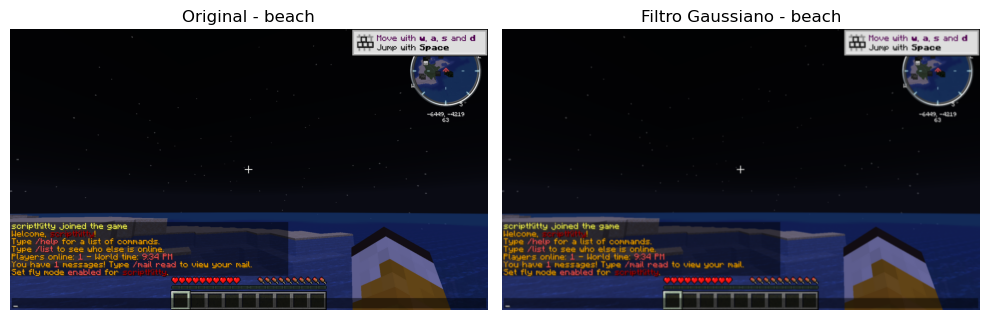

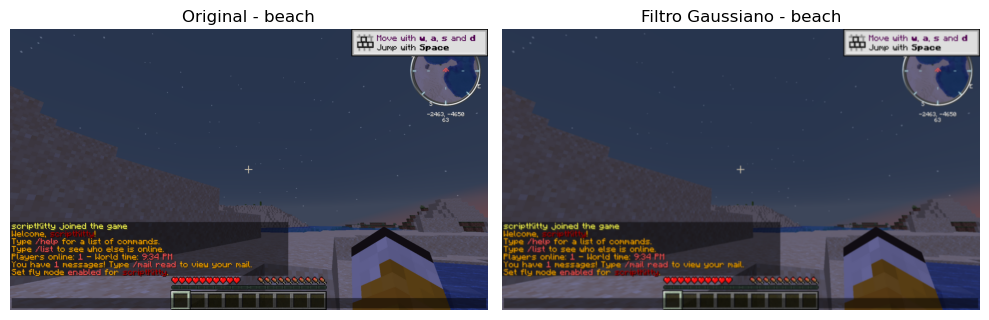

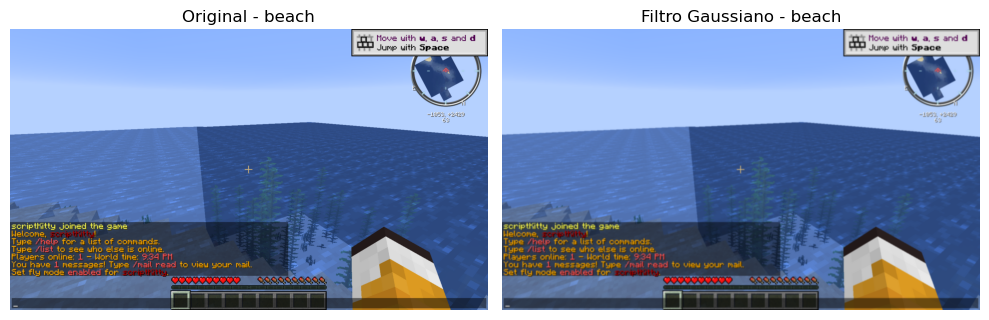

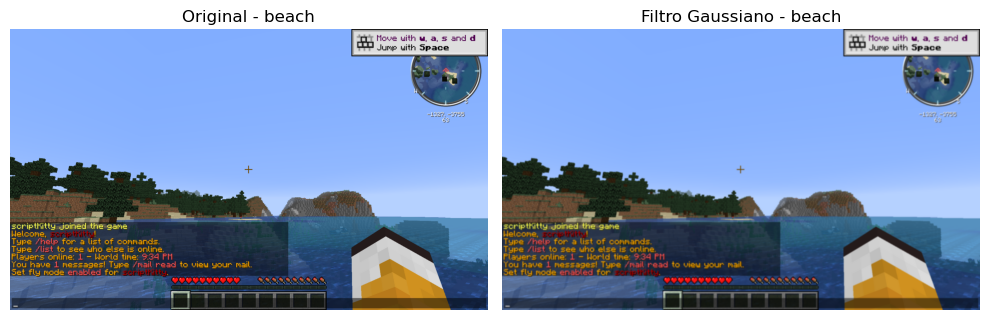

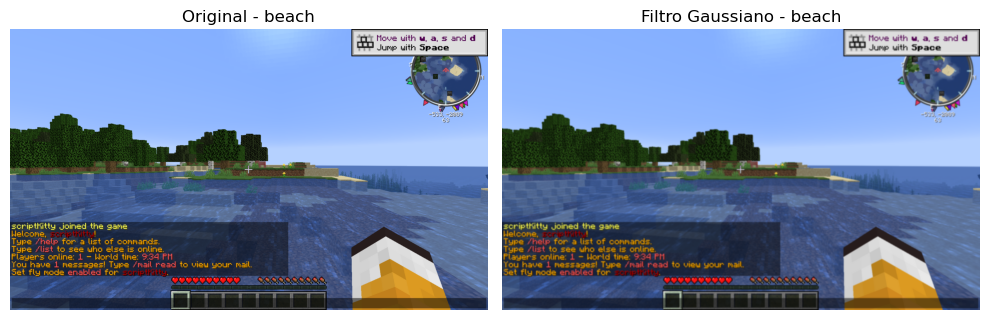

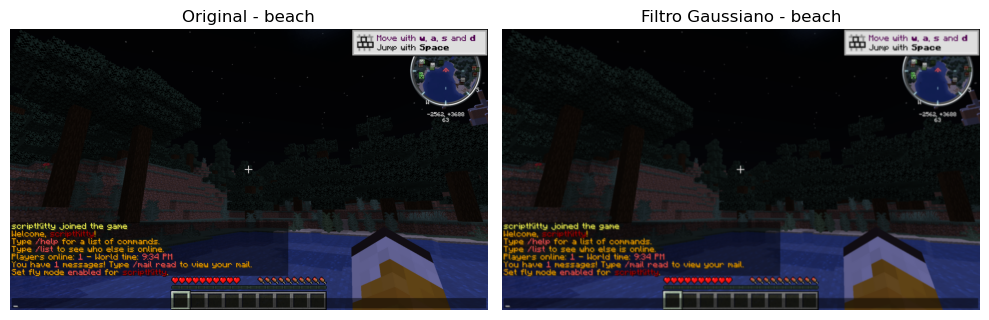

In [30]:
import os
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

# Ruta al dataset
dataset_path = r'C:\Users\leo_m\OneDrive - Benemérita Universidad Autónoma de Puebla\Cursos\Diplomado Ciencia de Datos\M6 Redes neuronales\Proyecto 2\MinecraftBiomesDataset'

# Verificamos si la ruta existe
print("Ruta existe:", os.path.exists(dataset_path))
if os.path.exists(dataset_path):
    print("Biomas encontrados:")
    print(os.listdir(dataset_path))
else:
    print("❌ No se encontró la ruta. Verifica que esté bien escrita.")

# Cargar imágenes y etiquetas
image_paths = []
labels = []

extensiones = ['*.png', '*.jpg', '*.jpeg']

for biome in os.listdir(dataset_path):
    folder = os.path.join(dataset_path, biome)
    if os.path.isdir(folder):
        for ext in extensiones:
            for img_path in glob(os.path.join(folder, ext)):
                image_paths.append(img_path)
                labels.append(biome)

print(f"Total de rutas de imágenes encontradas: {len(image_paths)}")

# Función para mostrar imágenes
def show_images(original, filtered, label, filtro):
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(original)
    axs[0].set_title(f"Original - {label}")
    axs[0].axis('off')
    axs[1].imshow(filtered)
    axs[1].set_title(f"{filtro} - {label}")
    axs[1].axis('off')
    plt.tight_layout()
    plt.show()

# Procesar y mostrar imágenes con filtro Gaussiano
procesadas = 0
max_imagenes = 6

for img_path, label in zip(image_paths, labels):
    try:
        # Abrir imagen con PIL y convertir a array
        img_pil = Image.open(img_path).convert('RGB')
        img_np = np.array(img_pil)

        # Convertir a formato BGR para OpenCV
        img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

        # Aplicar filtro Gaussiano
        filtered_bgr = cv2.GaussianBlur(img_bgr, (7, 7), 0)

        # Convertir de vuelta a RGB para mostrar
        filtered_rgb = cv2.cvtColor(filtered_bgr, cv2.COLOR_BGR2RGB)

        # Mostrar
        show_images(img_pil, filtered_rgb, label, "Filtro Gaussiano")

        procesadas += 1
        if procesadas >= max_imagenes:
            break
    except Exception as e:
        print(f"❌ Error al procesar {img_path}: {e}")


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# Lista para imágenes procesadas y etiquetas
imagenes_filtradas = []
etiquetas_codificadas = []

# Tamaño deseado
size = (64, 64)

for img_path, label in zip(image_paths, labels):
    try:
        # Cargar imagen
        img_pil = Image.open(img_path).convert('RGB')
        img_np = np.array(img_pil)

        # Convertir a BGR
        img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

        # Aplicar filtro Gaussiano
        filtered_bgr = cv2.GaussianBlur(img_bgr, (7, 7), 0)

        # Redimensionar y convertir a RGB
        filtered_bgr = cv2.resize(filtered_bgr, size)
        filtered_rgb = cv2.cvtColor(filtered_bgr, cv2.COLOR_BGR2RGB)

        # Normalizar
        filtered_rgb = filtered_rgb.astype('float32') / 255.0

        # Guardar
        imagenes_filtradas.append(filtered_rgb)
        etiquetas_codificadas.append(label)

    except Exception as e:
        print(f"❌ Error al procesar {img_path}: {e}")

# Convertir listas a numpy arrays
X = np.array(imagenes_filtradas)
print("Shape de X:", X.shape)

# Codificar etiquetas
le = LabelEncoder()
y_encoded = le.fit_transform(etiquetas_codificadas)
y_categorical = to_categorical(y_encoded)
print("Shape de y:", y_categorical.shape)

# Separar en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)


Shape de X: (104, 64, 64, 3)
Shape de y: (104, 7)


In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Definir el modelo
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(le.classes_), activation='softmax')  # Una neurona por clase
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Entrenamiento
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)


C:\Users\leo_m\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.1346 - loss: 2.0383 - val_accuracy: 0.1765 - val_loss: 1.9400
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.2965 - loss: 1.7807 - val_accuracy: 0.2941 - val_loss: 1.8574
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.2386 - loss: 1.8476 - val_accuracy: 0.3529 - val_loss: 1.8449
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3918 - loss: 1.7428 - val_accuracy: 0.2941 - val_loss: 1.8757
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4118 - loss: 1.6102 - val_accuracy: 0.4118 - val_loss: 1.6694
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5540 - loss: 1.3877 - val_accuracy: 0.4706 - val_loss: 1.5299
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5308 - loss: 1.3488 - val_accuracy: 0.4706 - val_loss: 1.4968
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5349 - loss: 1.4603 - val_accuracy: 0.5294 - val_loss: 1.4569

In [39]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Precisión en test: {acc:.2%}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3810 - loss: 1.4465
Precisión en test: 38.10%


Ruta existe: True
Biomas encontrados:
['.git', '.idea', 'beach', 'birch_forest', 'dark_forest', 'dessert', 'forest', 'ocean', 'swamp']
Total de rutas de imágenes encontradas: 104


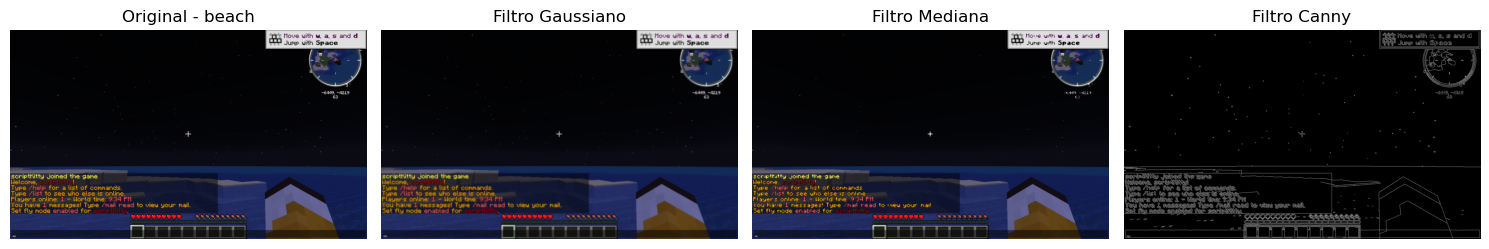

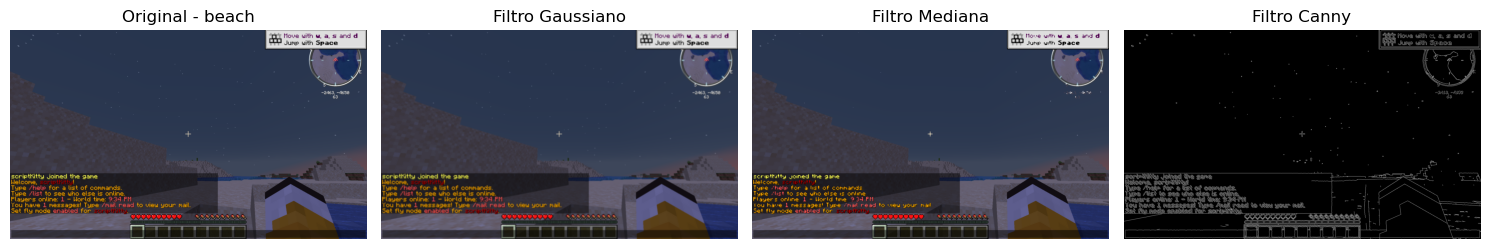

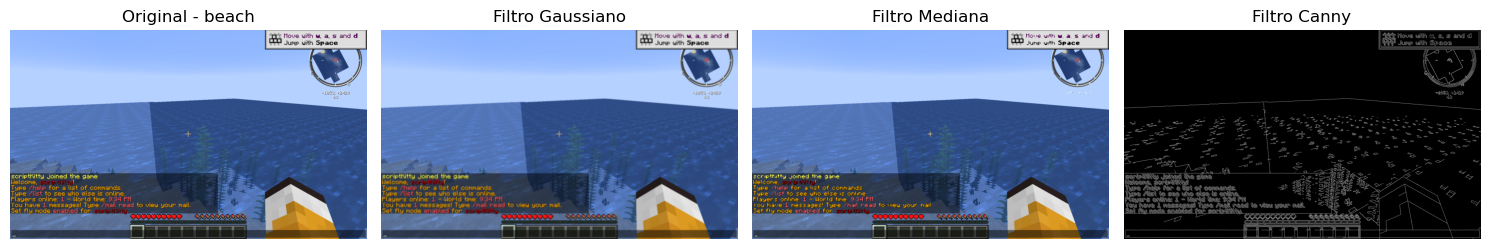

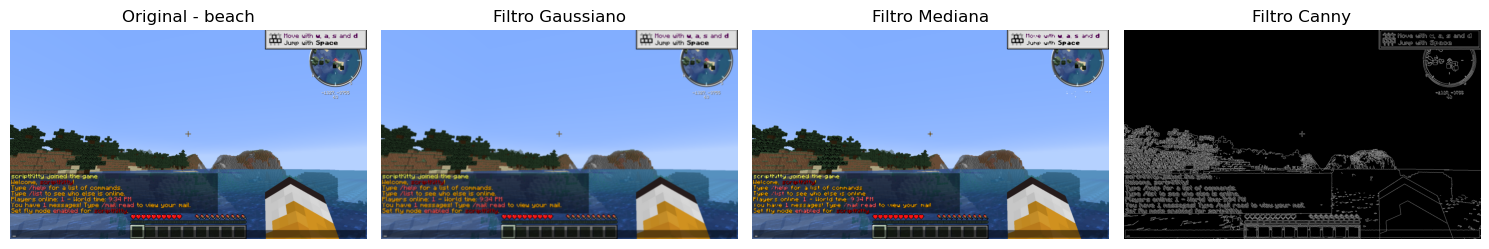

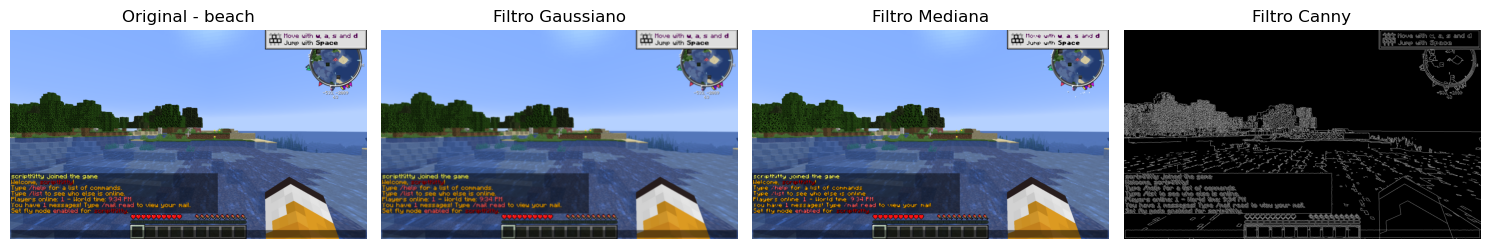

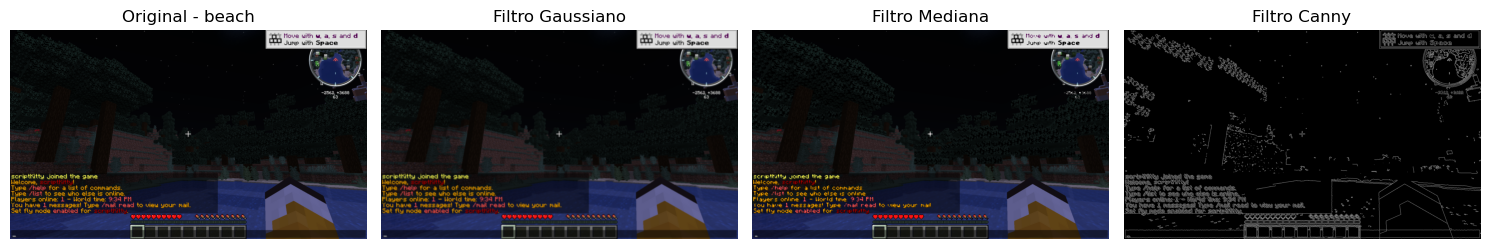

In [40]:
import os
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

# Ruta al dataset
dataset_path = r'C:\Users\leo_m\OneDrive - Benemérita Universidad Autónoma de Puebla\Cursos\Diplomado Ciencia de Datos\M6 Redes neuronales\Proyecto 2\MinecraftBiomesDataset'

# Verificar si la ruta existe
print("Ruta existe:", os.path.exists(dataset_path))
if os.path.exists(dataset_path):
    print("Biomas encontrados:")
    print(os.listdir(dataset_path))
else:
    print("❌ No se encontró la ruta. Verifica que esté bien escrita.")

# Cargar imágenes y etiquetas
image_paths = []
labels = []
extensiones = ['*.png', '*.jpg', '*.jpeg']

for biome in os.listdir(dataset_path):
    folder = os.path.join(dataset_path, biome)
    if os.path.isdir(folder):
        for ext in extensiones:
            for img_path in glob(os.path.join(folder, ext)):
                image_paths.append(img_path)
                labels.append(biome)

print(f"Total de rutas de imágenes encontradas: {len(image_paths)}")

# Función para mostrar imágenes originales + filtradas
def show_multiple_filters(original, filtered_list, label, filtro_nombres):
    fig, axs = plt.subplots(1, len(filtered_list) + 1, figsize=(15, 5))
    axs[0].imshow(original)
    axs[0].set_title(f"Original - {label}")
    axs[0].axis('off')

    for i, (filt, nombre) in enumerate(zip(filtered_list, filtro_nombres)):
        axs[i+1].imshow(filt)
        axs[i+1].set_title(nombre)
        axs[i+1].axis('off')

    plt.tight_layout()
    plt.show()

# Procesar y mostrar las imágenes con múltiples filtros
procesadas = 0
max_imagenes = 6

for img_path, label in zip(image_paths, labels):
    try:
        # Cargar imagen
        img_pil = Image.open(img_path).convert('RGB')
        img_np = np.array(img_pil)
        img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

        # Aplicar filtros
        gauss = cv2.GaussianBlur(img_bgr, (7, 7), 0)
        mediana = cv2.medianBlur(img_bgr, 5)
        canny = cv2.Canny(img_bgr, 100, 200)
        canny_rgb = cv2.cvtColor(canny, cv2.COLOR_GRAY2RGB)  # para mostrarlo con matplotlib

        # Convertir de nuevo a RGB
        gauss_rgb = cv2.cvtColor(gauss, cv2.COLOR_BGR2RGB)
        mediana_rgb = cv2.cvtColor(mediana, cv2.COLOR_BGR2RGB)

        # Mostrar todos los filtros
        show_multiple_filters(img_pil, [gauss_rgb, mediana_rgb, canny_rgb], label,
                              ["Filtro Gaussiano", "Filtro Mediana", "Filtro Canny"])

        procesadas += 1
        if procesadas >= max_imagenes:
            break
    except Exception as e:
        print(f"❌ Error al procesar {img_path}: {e}")


In [41]:
import os
import cv2
import numpy as np
from PIL import Image
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Dataset
dataset_path = r'C:\Users\leo_m\OneDrive - Benemérita Universidad Autónoma de Puebla\Cursos\Diplomado Ciencia de Datos\M6 Redes neuronales\Proyecto 2\MinecraftBiomesDataset'
extensiones = ['*.png', '*.jpg', '*.jpeg']
img_size = (64, 64)

# Cargar y procesar imágenes por tipo de filtro
def cargar_imagenes(filtro='gauss'):
    X, y = [], []

    for biome in os.listdir(dataset_path):
        folder = os.path.join(dataset_path, biome)
        if os.path.isdir(folder):
            for ext in extensiones:
                for img_path in glob(os.path.join(folder, ext)):
                    try:
                        img = Image.open(img_path).convert('RGB')
                        img = img.resize(img_size)
                        img_np = np.array(img)
                        img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

                        # Aplicar el filtro seleccionado
                        if filtro == 'gauss':
                            img_filtered = cv2.GaussianBlur(img_bgr, (7, 7), 0)
                        elif filtro == 'mediana':
                            img_filtered = cv2.medianBlur(img_bgr, 5)
                        elif filtro == 'canny':
                            canny = cv2.Canny(img_bgr, 100, 200)
                            img_filtered = cv2.cvtColor(canny, cv2.COLOR_GRAY2BGR)
                        else:
                            img_filtered = img_bgr  # sin filtro

                        img_rgb = cv2.cvtColor(img_filtered, cv2.COLOR_BGR2RGB)
                        X.append(img_rgb)
                        y.append(biome)
                    except:
                        continue

    return np.array(X), np.array(y)

# Procesar imágenes por filtro
X_gauss, y_gauss = cargar_imagenes('gauss')
X_mediana, y_mediana = cargar_imagenes('mediana')
X_canny, y_canny = cargar_imagenes('canny')


In [42]:
def preparar_datos(X, y):
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    y_cat = to_categorical(y_encoded)
    X_norm = X / 255.0
    return train_test_split(X_norm, y_cat, test_size=0.2, random_state=42), le


In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def crear_modelo(num_clases):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 3)),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_clases, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [44]:
def entrenar_y_evaluar(X, y, nombre):
    (X_train, X_test, y_train, y_test), le = preparar_datos(X, y)
    model = crear_modelo(num_clases=y_train.shape[1])
    print(f"Entrenando modelo con filtro {nombre}...")
    model.fit(X_train, y_train, epochs=15, batch_size=32, validation_split=0.2, verbose=1)
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Precisión en test con filtro {nombre}: {acc*100:.2f}%")
    return acc


In [45]:
acc_gauss = entrenar_y_evaluar(X_gauss, y_gauss, "Gaussiano")
acc_mediana = entrenar_y_evaluar(X_mediana, y_mediana, "Mediana")
acc_canny = entrenar_y_evaluar(X_canny, y_canny, "Canny")

print("\nResumen de precisión por filtro:")
print(f"Gaussiano: {acc_gauss*100:.2f}%")
print(f"Mediana: {acc_mediana*100:.2f}%")
print(f"Canny: {acc_canny*100:.2f}%")


Entrenando modelo con filtro Gaussiano...
Epoch 1/15


C:\Users\leo_m\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step - accuracy: 0.1768 - loss: 2.0201 - val_accuracy: 0.1176 - val_loss: 2.0405
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1883 - loss: 2.1092 - val_accuracy: 0.5294 - val_loss: 1.7913
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2924 - loss: 1.7884 - val_accuracy: 0.4118 - val_loss: 1.7835
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4270 - loss: 1.7292 - val_accuracy: 0.3529 - val_loss: 1.7251
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4770 - loss: 1.6389 - val_accuracy: 0.3529 - val_loss: 1.5888
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.4226 - loss: 1.5758 - val_accuracy: 0.4706 - val_loss: 1.4429
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.4458 - loss: 1.5305 - val_accuracy: 0.3529 - val_loss: 1.4031
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.3923 - loss: 1.5367 - val_accuracy: 0.4118 - val_loss: 1.3079
Epoch 9/1

C:\Users\leo_m\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - accuracy: 0.0887 - loss: 2.1146 - val_accuracy: 0.1765 - val_loss: 1.8989
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1461 - loss: 1.8883 - val_accuracy: 0.4706 - val_loss: 1.8503
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4536 - loss: 1.7945 - val_accuracy: 0.4118 - val_loss: 1.8097
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3803 - loss: 1.7605 - val_accuracy: 0.4706 - val_loss: 1.6964
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5923 - loss: 1.5699 - val_accuracy: 0.4706 - val_loss: 1.5383
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5533 - loss: 1.4421 - val_accuracy: 0.4706 - val_loss: 1.3781
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5459 - loss: 1.3254 - val_accuracy: 0.3529 - val_loss: 1.3326
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5889 - loss: 1.2696 - val_accuracy: 0.5882 - val_loss: 1.1896
Epoch 9/15

C:\Users\leo_m\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.1153 - loss: 2.2469 - val_accuracy: 0.2353 - val_loss: 1.9638
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.2076 - loss: 1.9996 - val_accuracy: 0.1176 - val_loss: 1.9199
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.2040 - loss: 1.8551 - val_accuracy: 0.1176 - val_loss: 1.9119
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3652 - loss: 1.7326 - val_accuracy: 0.1765 - val_loss: 1.9168
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.3649 - loss: 1.7326 - val_accuracy: 0.1765 - val_loss: 1.8990
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4536 - loss: 1.5457 - val_accuracy: 0.1176 - val_loss: 1.9217
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4880 - loss: 1.3766 - val_accuracy: 0.2941 - val_loss: 1.8909
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6810 - loss: 1.1423 - val_accuracy: 0.2941 - val_loss: 1.7722
Epoch 9/15

In [46]:
# Filtrado mediana
X_mediana, y_mediana = cargar_imagenes('mediana')


In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Codificar etiquetas y dividir
le = LabelEncoder()
y_encoded = le.fit_transform(y_mediana)
y_cat = to_categorical(y_encoded)
X_norm = X_mediana / 255.0

X_train, X_test, y_train, y_test = train_test_split(X_norm, y_cat, test_size=0.2, random_state=42)


In [48]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)


In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model = Sequential([
    Input(shape=(64, 64, 3)),  # Definir la entrada como la primera capa
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(y_cat.shape[1], activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])



In [52]:
history = model.fit(datagen.flow(X_train, y_train, batch_size=32),
                    epochs=30,
                    validation_data=(X_test, y_test))


Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.1524 - loss: 1.9876 - val_accuracy: 0.2857 - val_loss: 1.9383
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.3090 - loss: 1.7971 - val_accuracy: 0.3810 - val_loss: 1.7611
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.3210 - loss: 1.7669 - val_accuracy: 0.2857 - val_loss: 1.6546
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.4122 - loss: 1.5742 - val_accuracy: 0.3810 - val_loss: 1.5380
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.4317 - loss: 1.4511 - val_accuracy: 0.4762 - val_loss: 1.4427
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.4136 - loss: 1.4906 - val_accuracy: 0.4286 - val_loss: 1.4120
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.4573 - loss: 1.3993 - val_accuracy: 0.4762 - val_loss: 1.3514
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5087 - loss: 1.1841 - val_accuracy: 0.4762 - val_loss: 1.3307

In [53]:
model.save("modelo_minecraft_mediana.h5")
print("✅ Modelo guardado como modelo_minecraft_mediana.h5")


✅ Modelo guardado como modelo_minecraft_mediana.h5


In [55]:
# Evaluar el desempeño del modelo sobre el conjunto de test
loss, accuracy = model.evaluate(X_test, y_test)

print(f"🔍 Pérdida en el conjunto de test: {loss:.4f}")
print(f"🎯 Precisión en el conjunto de test: {accuracy * 100:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5714 - loss: 1.1645
🔍 Pérdida en el conjunto de test: 1.1645
🎯 Precisión en el conjunto de test: 57.14%


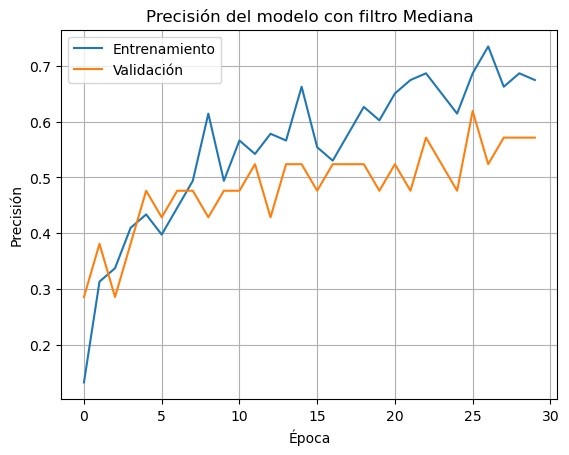

In [54]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del modelo con filtro Mediana')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid()
plt.show()
